# Введение

В руководстве мы узнали о строительных блоках нейронных сетей: линейных блоках. Мы увидели, что модель, состоящая всего из одного линейного блока, подбирает линейную функцию для набора данных (что эквивалентно линейной регрессии). В этом упражнении вы построите линейную модель и попрактикуетесь в работе с моделями в Keras.

Прежде чем начать, запустите ячейку с кодом ниже, чтобы настроить всё необходимое.

In [ ]:
python -m pip install matplotlib

In [3]:
# Настройка построения графиков
import matplotlib.pyplot as plt

print(plt.style.available)
plt.style.use('seaborn-v0_8-whitegrid')
# Установка настроек по умолчанию для Matplotlib
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)

# Настройка системы обратной связи для Kangle
# from learntools.core import binder
# binder.bind(globals())
# from learntools.deep_learning_intro.ex1 import *

['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'petroff6', 'petroff8', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


Набор данных Red Wine Quality (Качество красного вина) состоит из физико-химических измерений примерно 1600 португальских красных вин. Также включена оценка качества каждого вина, полученная в ходе «слепых» дегустаций.

Сначала запустите следующую ячейку, чтобы отобразить первые несколько строк этого набора данных.

In [7]:
import pandas as pd

# Загрузка данных о красном вине
red_wine = pd.read_csv('./data/red-wine.csv')
red_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Вы можете узнать количество строк и столбцов датафрейма (или массива Numpy) с помощью атрибута `shape`.

In [8]:
red_wine.shape # (строки, столбцы)

(1599, 12)

### 1) Размер входных данных (Input shape)

Насколько хорошо мы можем предсказать воспринимаемое качество вина на основе физико-химических измерений?

Целевая переменная — `'quality'`, а остальные столбцы являются признаками. Как бы вы установили параметр `input_shape` для модели Keras в этой задаче?

In [9]:
# ВАШ КОД ЗДЕСЬ
input_shape = [11]

# Проверка вашего ответа
# q_1.check()

In [ ]:
# Строки ниже дадут вам подсказку или код решения
#q_1.hint()
#q_1.solution()

### 2) Определение линейной модели

Теперь определите линейную модель, подходящую для этой задачи. Обратите внимание на то, сколько входов и выходов должно быть у модели.

In [12]:
from tensorflow import keras
from tensorflow.keras import layers

# ВАШ КОД ЗДЕСЬ
model = keras.Sequential([
    layers.Dense(units=1, input_shape=input_shape)
])

# Проверка вашего ответа
# q_2.check()

In [ ]:
# Строки ниже дадут вам подсказку или код решения
#q_2.hint()
#q_2.solution()

### 3) Изучение весов

Внутри Keras представляет веса нейронной сети с помощью тензоров. Тензоры — это, по сути, версия массивов Numpy от TensorFlow с несколькими отличиями, которые делают их более подходящими для глубокого обучения. Одно из самых важных — совместимость тензоров с ускорителями GPU и TPU. TPU, фактически, специально разработаны для тензорных вычислений.

Веса модели хранятся в её атрибуте `weights` в виде списка тензоров. Получите веса модели, которую вы определили выше. (Если хотите, вы можете вывести веса примерно так: `print("Веса\n{}\n\nСмещение\n{}".format(w, b))`).

In [15]:
# ВАШ КОД ЗДЕСЬ
w, b = model.weights

print("Weights\n{}\n\nBias\n{}".format(w, b))

# Проверка вашего ответа
# q_3.check()

Weights
<Variable path=sequential_2/dense_2/kernel, shape=(11, 1), dtype=float32, value=[[ 0.23343754]
 [ 0.4802428 ]
 [ 0.42648917]
 [ 0.21244437]
 [-0.33274177]
 [ 0.6869611 ]
 [ 0.3868521 ]
 [-0.14683205]
 [-0.56395435]
 [-0.19259691]
 [-0.62915736]]>

Bias
<Variable path=sequential_2/dense_2/bias, shape=(1,), dtype=float32, value=[0.]>


In [ ]:
# Строки ниже дадут вам подсказку или код решения
#q_3.hint()
#q_3.solution()

(Кстати, Keras представляет веса в виде тензоров, но также использует тензоры для представления данных. Когда вы задаете аргумент `input_shape`, вы сообщаете Keras размерность массива, который он должен ожидать для каждого примера в обучающих данных. Установка `input_shape=[3]` создаст сеть, принимающую векторы длиной 3, например `[0.2, 0.4, 0.6]`).

### Дополнительно: Построение графика вывода необученной линейной модели

Задачи, над которыми мы будем работать до 5-го урока, будут задачами регрессии, где целью является предсказание некоторого числового значения. Задачи регрессии похожи на задачи «подбора кривой»: мы пытаемся найти кривую, которая лучше всего соответствует данным. Давайте посмотрим на «кривую», создаваемую линейной моделью. (Вы, вероятно, догадались, что это прямая!)

Мы упоминали, что до начала обучения веса модели устанавливаются случайным образом. Запустите ячейку ниже несколько раз, чтобы увидеть разные прямые, созданные при случайной инициализации. (В этом упражнении не нужно писать код — это просто демонстрация.)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


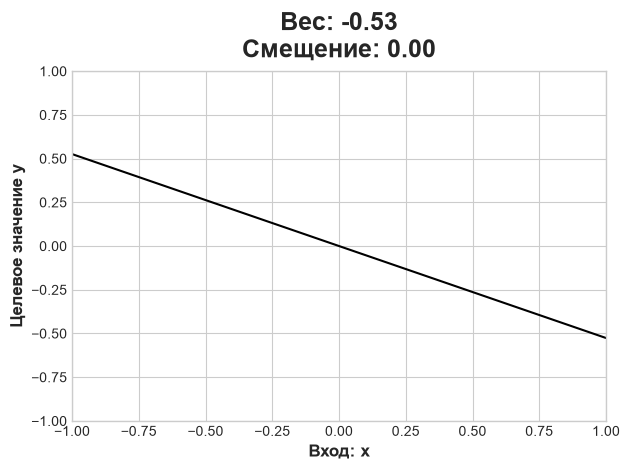

In [19]:
import tensorflow as tf
import matplotlib.pyplot as plt

model = keras.Sequential([
    layers.Dense(1, input_shape=[1]),
])

x = tf.linspace(-1.0, 1.0, 100)
y = model.predict(x)

plt.figure(dpi=100)
plt.plot(x, y, 'k')
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xlabel("Вход: x")
plt.ylabel("Целевое значение y")
w, b = model.weights # здесь также можно использовать model.get_weights()
plt.title("Вес: {:0.2f}\nСмещение: {:0.2f}".format(w[0][0], b[0]))
plt.show()

### Продолжайте движение!

Добавляйте скрытые слои и делайте ваши модели глубокими во 2-м уроке.